# Neural Network for Weekly Sales Forecasting

Trong notebook này, chúng ta sẽ:
- Chuẩn hoá dữ liệu đầu vào.
- Xây dựng mô hình mạng nơ-ron nhân tạo (Neural Network) để dự đoán `Weekly_Sales`.
- Đánh giá mô hình bằng các chỉ số Mean Squared Error (MSE) và R-squared (R²).

In [2]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Đọc dữ liệu (giả định file trong cùng thư mục, tên là 'train.csv' và 'features.csv')
train_df = pd.read_csv('data/train.csv')
features_df = pd.read_csv('data/features.csv')

# Kết hợp dữ liệu dựa trên Store và Date
merged_df = pd.merge(train_df, features_df, on=['Store', 'Date'], how='inner')
print("Kích thước dữ liệu sau khi kết hợp:", merged_df.shape)

Kích thước dữ liệu sau khi kết hợp: (421570, 15)


### 1. Tiền xử lý dữ liệu

In [3]:
# Trích xuất các đặc trưng từ cột Date
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Week'] = merged_df['Date'].dt.isocalendar().week
merged_df['DayOfWeek'] = merged_df['Date'].dt.dayofweek

# Chọn các cột cần thiết
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'DayOfWeek']
X = merged_df[features]
y = merged_df['Weekly_Sales']

# Kiểm tra giá trị bị thiếu
print("Giá trị bị thiếu:")
print(X.isnull().sum())

# Điền khuyết nếu cần thiết
X.fillna(method='ffill', inplace=True)

# Chuẩn hoá dữ liệu bằng Min-Max Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)

Giá trị bị thiếu:
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
DayOfWeek       0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10232\2341235866.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10232\2341235866.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(method='ffill', inplace=True)


Kích thước tập huấn luyện: (337256, 8) (337256,)


### 2. Xây dựng mô hình mạng nơ-ron nhân tạo

In [5]:
# Xây dựng mô hình Neural Network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer
])

# Biên dịch mô hình
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Hiển thị kiến trúc mô hình
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Huấn luyện mô hình

In [6]:
# Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 543129536.0000 - mae: 15104.3193 - val_loss: 519867264.0000 - val_mae: 15084.9434
Epoch 2/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 511207264.0000 - mae: 15068.9570 - val_loss: 519206144.0000 - val_mae: 15559.9141
Epoch 3/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 509158912.0000 - mae: 15078.6865 - val_loss: 518380800.0000 - val_mae: 15010.9902
Epoch 4/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 511313088.0000 - mae: 15082.6816 - val_loss: 518481472.0000 - val_mae: 14961.1826
Epoch 5/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 514219616.0000 - mae: 15052.8574 - val_loss: 518021632.0000 - val_mae: 15136.9463
Epoch 6/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 513130208.0000 - mae: 15091.8145 - val_loss: 518089984.0000 - val_mae: 15012.9238
Epoch 7/50
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 517692064.0000 - mae: 15109.1514 - val_loss: 518033888.0000 - val_m

### 4. Đánh giá mô hình

In [7]:
# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Tính toán MSE và R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

2635/2635 ━━━━━━━━━━━━━━━━━━━━ 2s 608us/step
Mean Squared Error (MSE): 522824925.91927534
R-squared (R²): -0.002596372684210646


### 5. Vẽ biểu đồ tổn thất (Loss) trong quá trình huấn luyện

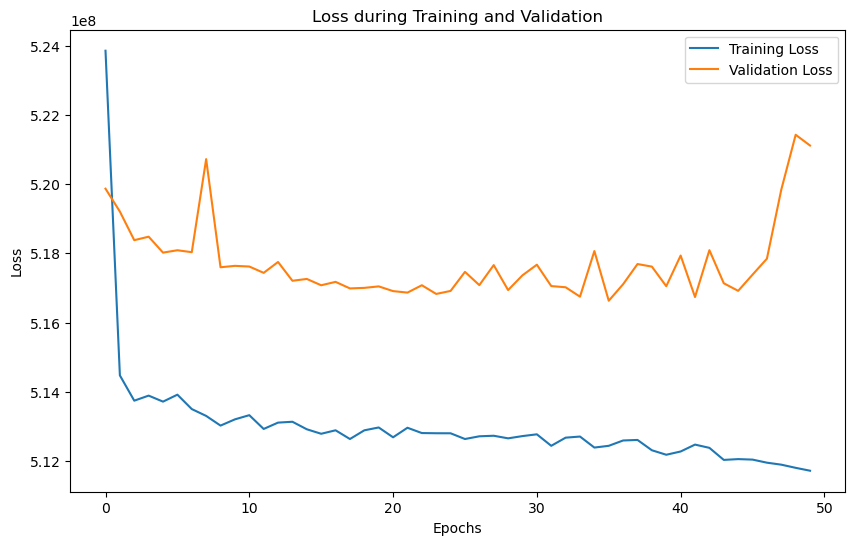

In [8]:
# Vẽ biểu đồ loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during Training and Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Tổng kết:
- Mô hình mạng nơ-ron đã được xây dựng và huấn luyện trên dữ liệu chuẩn hoá.
- Độ chính xác của mô hình được đánh giá qua MSE và R².
- Biểu đồ tổn thất giúp kiểm tra quá trình hội tụ của mô hình.